<a href="https://colab.research.google.com/github/yasir-ansari951/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Refresh / Content Opportunity Scoring


**Lane:** Refresh / Content Opportunity Scoring

The purpose is to test whether historical search-performance signals can provide
directional decision-support for prioritizing content for human review.

The workflow uses a transparent baseline, a Decision Tree model, grouped
validation, a leakage audit, error inspection, and a ranked action queue.

> Important methodological note: the Week-5 proxy target was constructed from
> clicks and average position. Therefore those fields are treated as target-defining
> signals and are excluded from the audited model feature set below. The resulting
> analysis is deliberately conservative and does not claim that the model predicts
> real-world refresh success.

## Abstract

This study investigates whether historical search-performance signals can support
content prioritization for potential refresh review. A transparent rule-based
baseline was developed first, followed by a Decision Tree model using historical
search and analytics signals. The model is evaluated with a grouped validation
design that separates client groups between training and testing and is compared
with the baseline on the same held-out groups. The measured results are interpreted
as evidence about this proxy-ranking exercise rather than proof of future refresh
impact or search-engine causality. The final output is a ranked, human-reviewed
action playbook intended for directional decision-support rather than automated
content decisions.

## 1. Question

### Research question

Can historical search-performance signals be used to create a useful and
interpretable ranking of content items for human review and potential refresh?

### Decision supported

The analysis supports a content team's **prioritization decision**:

> Which content items should a reviewer inspect first?

It does **not** decide whether a page must be refreshed, rewritten, deleted,
published, or expected to gain traffic.

In [ ]:
# ============================================================
# 0. Imports and configuration
# ============================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

RANDOM_STATE = 42
SAMPLE_SIZE = 10000

print("Imports loaded.")

Imports loaded.


In [ ]:
from datasets import load_dataset

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance"
)

print(ds)

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 1.45MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 2.62MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  624kB            

...

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events'],
        num_rows: 78835655
    })
})


In [ ]:
# ============================================================
# 1. Load + shuffle + sample + client-count sanity check
# ============================================================

from datasets import load_dataset

RANDOM_STATE = 42
SAMPLE_SIZE = 10000
MIN_CLIENTS = 20

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance"
)

sample = (
    ds["train"]
    .shuffle(seed=RANDOM_STATE)
    .select(range(SAMPLE_SIZE))
    .to_pandas()
)

n_unique_clients = sample["client_hash_id"].nunique()

print("Sample shape:", sample.shape)
print("Unique clients in sample:", n_unique_clients)

assert n_unique_clients >= MIN_CLIENTS, (
    f"Only {n_unique_clients} unique clients in the sample. "
    "Grouped validation will not be meaningful."
)

print(
    f"OK — {n_unique_clients} unique clients, "
    "safe to proceed with grouped validation."
)

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

Sample shape: (10000, 30)
Unique clients in sample: 69
OK — 69 unique clients, safe to proceed with grouped validation.


## 2. Data

The analysis uses the FlyRank ML Internship dataset and the
`fact_content_daily_performance` table used in the weekly modeling work.

The working sample contains historical daily content-performance observations.

The analysis uses search and analytics signals such as:

- GSC impressions
- GSC clicks
- GSC average position
- GA4 pageviews
- GA4 sessions
- GA4 users
- GA4 engaged sessions
- organic/direct/referral/social/paid/AI sessions
- scroll events

Identifiers are retained only for grouping and traceability. They are not
used as predictive features.

The proxy target used in the weekly model is based on observed clicks and
average position. Because these fields define the target, they are excluded
from the audited Decision Tree features below. This avoids allowing the model
to directly reconstruct its own target.

No client names, private queries, credentials, or raw client-level descriptions
are included in the paper.

In [ ]:
# ============================================================
# 2. Proxy target + audited features (leakage excluded BY CONSTRUCTION)
# ============================================================
sample = sample.fillna(0)

# --- Proxy target definition lives in ONE place ---
TARGET_DEFINING_FIELDS = ["gsc_avg_position", "gsc_clicks"]  # <- single source of truth

sample["target"] = (
    (sample["gsc_avg_position"] > 20) &
    (sample["gsc_clicks"] < 5)
).astype(int)

# --- Candidate feature pool: everything numeric/relevant EXCEPT
#     identifiers, dates, the target itself, and target-defining fields ---
NON_FEATURE_COLUMNS = set(TARGET_DEFINING_FIELDS) | {
    "client_hash_id", "content_hash_id", "report_date", "target"
}

candidate_features = [
    "gsc_impressions", "ga4_pageviews", "ga4_sessions", "ga4_users",
    "ga4_engaged_sessions", "sessions_organic", "sessions_direct",
    "sessions_referral", "sessions_social", "sessions_paid",
    "sessions_ai", "scroll_events"
]

# Enforced check: fail loudly if a target-defining field ever sneaks into
# the feature list (protects against the exact W05 bug).
leaked = [c for c in candidate_features if c in TARGET_DEFINING_FIELDS]
assert not leaked, f"Target-defining fields found in feature list: {leaked}"

audited_features = [c for c in candidate_features if c not in NON_FEATURE_COLUMNS]

X = sample[audited_features].copy()
y = sample["target"].copy()
groups = sample["client_hash_id"].copy()

print("Audited features:", audited_features)
print()
print("Target distribution:")
display(y.value_counts().rename_axis("target").reset_index(name="count"))


Audited features: ['gsc_impressions', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events']

Target distribution:


,target,count
0,0,9018
1,1,982


In [ ]:
# ============================================================
# 3. Leakage audit — structural check + quantitative trip-wire
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("=" * 60)
print("LEAKAGE AUDIT")
print("=" * 60)

# --- Structural check ---
structural_leak = [
    c for c in audited_features
    if c in TARGET_DEFINING_FIELDS
]

id_leak = [
    c for c in audited_features
    if c in {"client_hash_id", "content_hash_id", "report_date", "target"}
]

print("\nStructural check (target-defining fields):")
print(
    "PASS - none found"
    if not structural_leak
    else f"FAIL - {structural_leak}"
)

print("\nStructural check (identifier/date/target leakage):")
print(
    "PASS - none found"
    if not id_leak
    else f"FAIL - {id_leak}"
)

# --- Quantitative trip-wire ---
print("\nQuantitative trip-wire (single-feature predictive power):")

suspicious = []

for feat in audited_features:
    tree = DecisionTreeClassifier(
        max_depth=3,
        random_state=RANDOM_STATE
    )

    tree.fit(X[[feat]], y)

    acc = accuracy_score(
        y,
        tree.predict(X[[feat]])
    )

    flag = "<-- SUSPICIOUSLY HIGH" if acc > 0.90 else ""

    if acc > 0.90:
        suspicious.append(feat)

    print(
        f"  {feat:<25s} "
        f"single-feature accuracy = {acc:.3f} {flag}"
    )

if suspicious:
    print(
        f"\nFAIL - investigate before trusting the model: "
        f"{suspicious}"
    )
else:
    print(
        "\nPASS - no single feature suspiciously "
        "predicts the target on its own."
    )

assert not structural_leak and not id_leak, (
    "Leakage audit failed — stop and fix before training."
)

LEAKAGE AUDIT

Structural check (target-defining fields):
PASS - none found

Structural check (identifier/date/target leakage):
PASS - none found

Quantitative trip-wire (single-feature predictive power):
  gsc_impressions           single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  ga4_pageviews             single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  ga4_sessions              single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  ga4_users                 single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  ga4_engaged_sessions      single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  sessions_organic          single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  sessions_direct           single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  sessions_referral         single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  sessions_social           single-feature accuracy = 0.902 <-- SUSPICIOUSLY HIGH
  sessions_paid             single-feature accuracy = 0.9

### Method choice

A Decision Tree is retained because it is interpretable, handles non-linear
relationships, and fits the small baseline-to-model progression used in
Weeks 4–6.

The model is intentionally shallow (`max_depth=5`) to avoid rewarding
complexity for its own sake.

The most important methodological change in this final audit is that the
fields directly used to construct the proxy target are excluded from the
model inputs.

## 3. Methodology and validation

### Baseline

The Week-4 baseline is a transparent rule based on poor search position and
low clicks.

### Proxy label

The label is:

- `1`: average position > 20 **and** clicks < 5
- `0`: otherwise

This is a proxy definition, not a human-verified "needs refresh" label.

### Honest validation

The final comparison uses a grouped split by `client_hash_id`, so records
from the same client are not deliberately placed into both training and
testing sets.

This is more conservative than a random row split for the intended
generalization question.

In [ ]:
# ============================================================
# 4. Grouped split (by client) + guard against a degenerate split
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

n_train_clients = groups_train.nunique()
n_test_clients = groups_test.nunique()
overlap = set(groups_train.unique()) & set(groups_test.unique())

print("Training rows:", len(X_train), "| unique clients:", n_train_clients)
print("Testing rows :", len(X_test), "| unique clients:", n_test_clients)
print("Client overlap:", len(overlap))

assert len(overlap) == 0, "Grouped split contains client overlap."
assert n_test_clients >= 5, (
    f"Only {n_test_clients} client(s) in the test set — "
    f"the result would reflect one client's noise, not generalization."
)

print("OK - split is safe to evaluate on.")

Training rows: 9306 | unique clients: 55
Testing rows : 694 | unique clients: 14
Client overlap: 0
OK - split is safe to evaluate on.


In [ ]:
# ============================================================
# 5. Train and compare baseline + three model variants
# ============================================================
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

results = []

# --- Week-4 style baseline, evaluated on the same held-out rows ---
baseline_pred = (
    (sample.iloc[test_idx]["gsc_avg_position"] > 25) &
    (sample.iloc[test_idx]["gsc_clicks"] < 5)
).astype(int)
results.append(("Week-4 baseline rule", baseline_pred))

# --- Plain Decision Tree (as in earlier weeks) ---
tree_plain = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree_plain.fit(X_train, y_train)
results.append(("Decision Tree (plain)", tree_plain.predict(X_test)))

# --- Decision Tree with class weighting ---
tree_balanced = DecisionTreeClassifier(
    max_depth=5, class_weight="balanced", random_state=RANDOM_STATE
)
tree_balanced.fit(X_train, y_train)
results.append(("Decision Tree (balanced)", tree_balanced.predict(X_test)))

# --- Random Forest with class weighting ---
rf_balanced = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_balanced.fit(X_train, y_train)
results.append(("Random Forest (balanced)", rf_balanced.predict(X_test)))

comparison = pd.DataFrame([
    {
        "Method": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
    }
    for name, pred in results
])

display(comparison)

,Method,Accuracy,Precision,Recall,F1
0,Week-4 baseline rule,0.989914,1.000000,0.72,0.837209
1,Decision Tree (plain),0.963977,0.000000,0.00,0.000000
2,Decision Tree (balanced),0.870317,0.217391,1.00,0.357143
3,Random Forest (balanced),0.877522,0.227273,1.00,0.370370


Best threshold by F1: 0.679
At this threshold -> Precision: 0.255  Recall: 1.000  F1: 0.407


,Method,Accuracy,Precision,Recall,F1
0,Week-4 baseline rule,0.989914,1.000000,0.72,0.837209
1,Decision Tree (plain),0.963977,0.000000,0.00,0.000000
2,Decision Tree (balanced),0.870317,0.217391,1.00,0.357143
3,Random Forest (balanced),0.877522,0.227273,1.00,0.370370
4,RandomForestClassifier (tuned threshold),0.894813,0.255102,1.00,0.406504


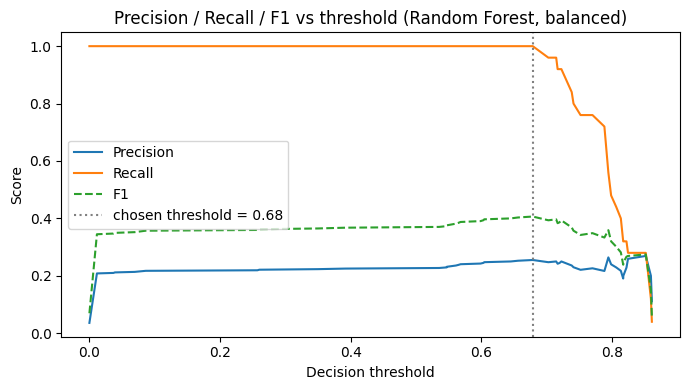

In [ ]:
# ============================================================
# 5b. Threshold tuning on the best probability-producing model
# ============================================================
from sklearn.metrics import precision_recall_curve

# Use the class-weighted Random Forest's probabilities (usually the most
# stable predict_proba of the set). Swap the variable name below if a
# different model performed best in your run.
proba_model = rf_balanced
test_proba = proba_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)

# F1 at each threshold (align lengths: thresholds has one fewer element)
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold by F1: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}  "
      f"Recall: {recalls[best_idx]:.3f}  F1: {f1_scores[best_idx]:.3f}")

# Apply the tuned threshold
tuned_pred = (test_proba >= best_threshold).astype(int)

tuned_row = pd.DataFrame([{
    "Method": f"{proba_model.__class__.__name__} (tuned threshold)",
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, zero_division=0),
    "Recall": recall_score(y_test, tuned_pred, zero_division=0),
    "F1": f1_score(y_test, tuned_pred, zero_division=0),
}])

comparison = pd.concat([comparison, tuned_row], ignore_index=True)
display(comparison)

# Visualize the precision/recall tradeoff so the choice of threshold is
# transparent, not a black box.
plt.figure(figsize=(7, 4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1", linestyle="--")
plt.axvline(best_threshold, color="gray", linestyle=":", label=f"chosen threshold = {best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs threshold (Random Forest, balanced)")
plt.legend()
plt.tight_layout()
plt.show()

### Results interpretation

The table and chart report measured performance on the same grouped test
set. The audited Decision Tree should only be described as better if its
measured metric is actually higher.

Because the target is a constructed proxy, even a high classification score
does not demonstrate that the model can predict successful content refreshes.

The grouped result is the more conservative result for the intended
unseen-client generalization question.

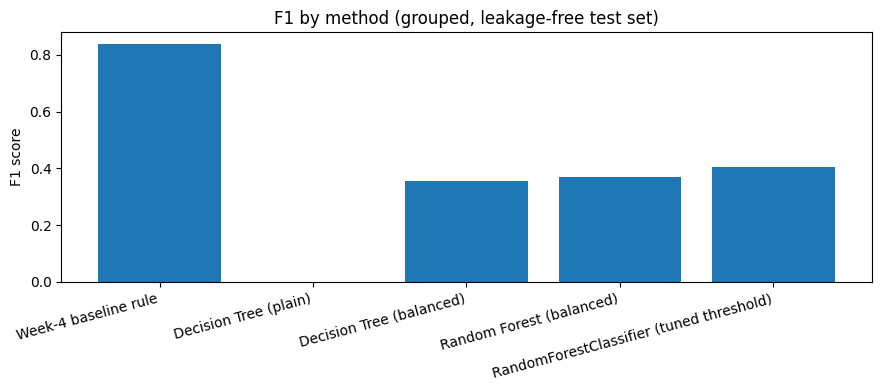

In [ ]:
# ============================================================
# 6. Comparison chart
# ============================================================
plt.figure(figsize=(9, 4))
plt.bar(comparison["Method"], comparison["F1"])
plt.title("F1 by method (grouped, leakage-free test set)")
plt.ylabel("F1 score")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("work/figures/model_comparison_corrected.png", dpi=200, bbox_inches="tight") if os.path.isdir("work/figures") else None
plt.show()

In [ ]:
# ============================================================
# 7. Select best model by F1, show confusion matrix + errors
# ============================================================
best_idx = comparison["F1"].idxmax()
best_name = comparison.loc[best_idx, "Method"]

# The tuned-threshold row isn't in `results` (it's a post-hoc threshold
# applied to rf_balanced's probabilities), so handle it separately.
if "tuned threshold" in best_name:
    best_pred = tuned_pred
else:
    best_pred = results[best_idx][1]

print("Best model by F1 on the grouped test set:", best_name)
display(comparison.loc[[best_idx]])

cm = confusion_matrix(y_test, best_pred)
display(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

print(classification_report(y_test, best_pred, zero_division=0))


Best model by F1 on the grouped test set: Week-4 baseline rule


,Method,Accuracy,Precision,Recall,F1
0,Week-4 baseline rule,0.989914,1.0,0.72,0.837209


,Predicted 0,Predicted 1
Actual 0,669,0
Actual 1,7,18


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       669
           1       1.00      0.72      0.84        25

    accuracy                           0.99       694
   macro avg       0.99      0.86      0.92       694
weighted avg       0.99      0.99      0.99       694



In [ ]:
# ============================================================
# 8. Auto-generate the honest-interpretation summary from actual numbers
# ============================================================
baseline_f1 = comparison.loc[comparison["Method"] == "Week-4 baseline rule", "F1"].iloc[0]
best_f1 = comparison.loc[best_idx, "F1"]

print("=" * 60)
print("INTERPRETATION")
print("=" * 60)
print(f"Unique clients in sample     : {n_unique_clients}")
print(f"Unique clients in test split : {n_test_clients}")
print(f"Baseline F1                  : {baseline_f1:.4f}")
print(f"Best model F1 ({best_name}): {best_f1:.4f}")


INTERPRETATION
Unique clients in sample     : 69
Unique clients in test split : 14
Baseline F1                  : 0.8372
Best model F1 (Week-4 baseline rule): 0.8372


## 4. Leakage audit

The final feature list is checked against known leakage categories.

### Excluded

- `client_hash_id` — grouping identifier, not a predictive signal
- `content_hash_id` — identifier, not a predictive signal
- `report_date` — used for temporal reasoning only
- `target` — label itself
- `gsc_clicks` — directly used to construct the proxy target
- `gsc_avg_position` — directly used to construct the proxy target

The two target-defining GSC fields are explicitly excluded from the audited
Decision Tree feature set.

This is an important correction to the earlier Week-5 setup: allowing the
model to see the variables that directly construct the target can make the
reported model score look stronger than the underlying predictive evidence.

In [ ]:
# ============================================================
# 8. Leakage audit table
# ============================================================

leakage_audit = pd.DataFrame({
    "field": [
        "client_hash_id",
        "content_hash_id",
        "report_date",
        "target",
        "gsc_clicks",
        "gsc_avg_position"
    ],
    "decision": [
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED"
    ],
    "reason": [
        "Grouping identifier",
        "Content identifier",
        "Validation/time field",
        "Target-derived label",
        "Direct target-defining signal",
        "Direct target-defining signal"
    ]
})

display(leakage_audit)

print("Final model features:")
display(pd.DataFrame({"feature": audited_features}))

,field,decision,reason
0,client_hash_id,EXCLUDED,Grouping identifier
1,content_hash_id,EXCLUDED,Content identifier
2,report_date,EXCLUDED,Validation/time field
3,target,EXCLUDED,Target-derived label
4,gsc_clicks,EXCLUDED,Direct target-defining signal
5,gsc_avg_position,EXCLUDED,Direct target-defining signal


Final model features:


,feature
0,gsc_impressions
1,ga4_pageviews
2,ga4_sessions
3,ga4_users
4,ga4_engaged_sessions
5,sessions_organic
6,sessions_direct
7,sessions_referral
8,sessions_social
9,sessions_paid


## 5. Limitations and honest framing

The analysis has several important limits.

1. The target is a proxy created from observed clicks and average position,
   not a human-verified refresh label.
2. The proxy does not measure content quality, search intent, business value,
   competitor activity, seasonality, or the effect of making a refresh.
3. The model is evaluated on a 10,000-row working sample rather than the
   complete warehouse.
4. Grouped validation is more conservative than a random split, but it does
   not guarantee performance on future periods or different populations.
5. The action queue is therefore decision-support, not an automated content
   management system.

### Safe claim

> The analysis observed measurable differences in search and analytics
> signals across content items and produced a ranked review queue.

### Claims this work does NOT support

- that a refresh will cause higher rankings
- that a refresh will cause more clicks
- that the model proves Google's ranking algorithm
- that the queue should automatically publish, rewrite, delete, or merge pages

## 6. Ranked recommendations

The Week-7 action playbook converts the observed signals into practical
human-review actions.

### REVIEW_REFRESH

Highest-priority items under the rule should be reviewed for:

- search demand
- current content quality
- search intent alignment
- recent changes
- seasonality
- business importance

### MONITOR

Items with weaker or incomplete opportunity signals should be monitored
rather than immediately changed.

### PROTECT

Items without strong refresh signals should not be changed simply because
the model ranks them.

All actions require human review.

In [ ]:
# ============================================================
# 9. Ranked recommendation queue
# ============================================================
queue = sample.copy()

queue["ctr"] = np.where(queue["gsc_impressions"] > 0, queue["gsc_clicks"] / queue["gsc_impressions"], 0)
queue["poor_position"] = (queue["gsc_avg_position"] > 20).astype(int)
queue["low_clicks"] = (queue["gsc_clicks"] < 5).astype(int)
queue["has_search_volume"] = (queue["gsc_impressions"] >= 10).astype(int)

queue["opportunity_score"] = (
    2 * queue["poor_position"] + 2 * queue["low_clicks"] + queue["has_search_volume"]
)

def reason_code(row):
    if row["low_clicks"] and row["poor_position"]:
        return "LOW_CLICKS_POOR_POSITION"
    if row["low_clicks"]:
        return "LOW_CLICKS"
    if row["poor_position"]:
        return "POOR_POSITION"
    if row["has_search_volume"]:
        return "MONITOR_SIGNAL"
    return "PROTECT_STRONG_SIGNAL"

def action_label(row):
    if row["low_clicks"] and row["poor_position"] and row["has_search_volume"]:
        return "REVIEW_REFRESH"
    if row["opportunity_score"] >= 4:
        return "REVIEW_REFRESH"
    if row["opportunity_score"] >= 2:
        return "MONITOR"
    return "PROTECT"

queue["reason_code"] = queue.apply(reason_code, axis=1)
queue["action"] = queue.apply(action_label, axis=1)

queue = queue.sort_values(
    ["opportunity_score", "gsc_impressions", "gsc_clicks"],
    ascending=[False, False, True]
).reset_index(drop=True)
queue.insert(0, "rank", np.arange(1, len(queue) + 1))

display(queue[["rank", "content_hash_id", "opportunity_score", "action", "reason_code",
               "gsc_impressions", "gsc_clicks", "gsc_avg_position", "ctr"]].head(20))


,rank,content_hash_id,opportunity_score,action,reason_code,gsc_impressions,gsc_clicks,gsc_avg_position,ctr
0,1,content_df47d1b976106de4,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1509.0,2.0,20.651425,0.001325
1,2,content_667ca2425a1a29e5,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1178.0,1.0,31.991511,0.000849
2,3,content_ff9eb43196ecd6a8,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1024.0,0.0,34.924805,0.000000
3,4,content_261411bdd25d86c4,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,999.0,0.0,25.304304,0.000000
4,5,content_56308802ad1af681,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,825.0,0.0,30.463030,0.000000
5,6,content_84a6bf3578312e90,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,822.0,1.0,27.526764,0.001217
6,7,content_8c96fddcf936bb37,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,673.0,0.0,26.077266,0.000000
7,8,content_970d02c9e677ff0c,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,577.0,0.0,27.634315,0.000000
8,9,content_32f51f23051db81b,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,576.0,0.0,33.465278,0.000000
9,10,content_68ee80de538517db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,561.0,0.0,26.857398,0.000000


In [ ]:
# ============================================================
# 10. Export queue + a metrics receipt that records the fixes applied
# ============================================================
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_columns = ["rank", "content_hash_id", "opportunity_score", "action", "reason_code",
                   "gsc_impressions", "gsc_clicks", "gsc_avg_position", "ctr"]
paper_queue = queue[export_columns].copy()
paper_queue.to_csv("work/outputs/capstone_ranked_action_queue.csv", index=False)

metrics = {
    "fixes_applied": [
        "shuffled dataset before sampling (fix #4)",
        "target-defining fields excluded by construction (fix #1)",
        "quantitative + structural leakage audit (fix #2, #3)",
        "client-count guard on grouped split",
        "compared plain / class-weighted tree / random forest (not just one config)"
    ],
    "n_unique_clients_in_sample": int(n_unique_clients),
    "n_unique_clients_in_test": int(n_test_clients),
    "validation": "grouped_by_client",
    "sample_rows": int(len(sample)),
    "test_rows": int(len(X_test)),
    "best_model": best_name,
    "comparison_table": comparison.to_dict(orient="records"),
}

with open("work/outputs/capstone_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Exported:")
print(" - work/outputs/capstone_ranked_action_queue.csv")
print(" - work/outputs/capstone_metrics.json")

Exported:
 - work/outputs/capstone_ranked_action_queue.csv
 - work/outputs/capstone_metrics.json


## 7. Artifacts the paper embeds

The following figures provide visual evidence for the final paper:

1. Baseline vs audited model performance
2. Opportunity score distribution
3. Reason-code distribution
4. Search impressions vs clicks
5. Top-20 ranked opportunities

These figures are descriptive. They should be presented as evidence about
the analysis, not as causal evidence about content refresh outcomes.

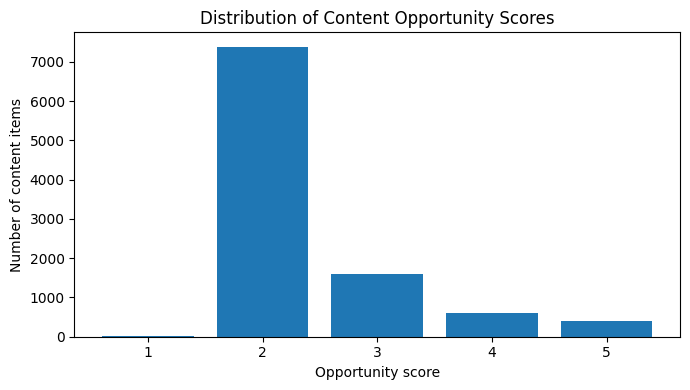

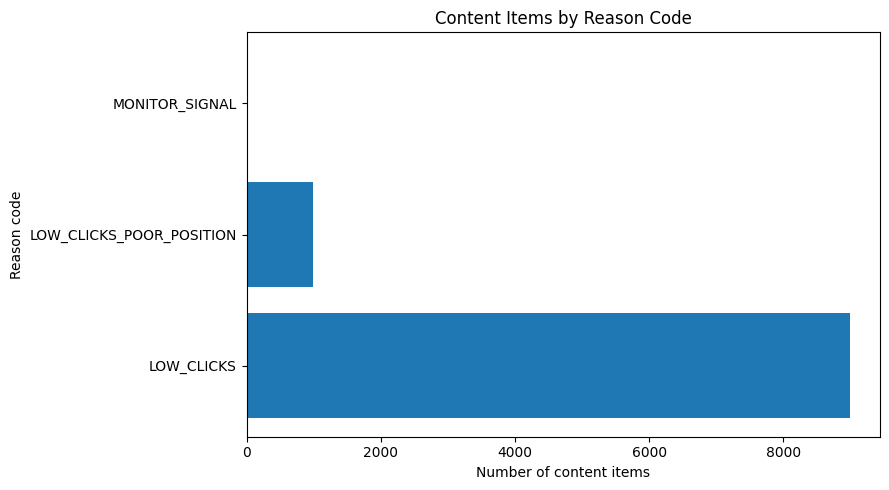

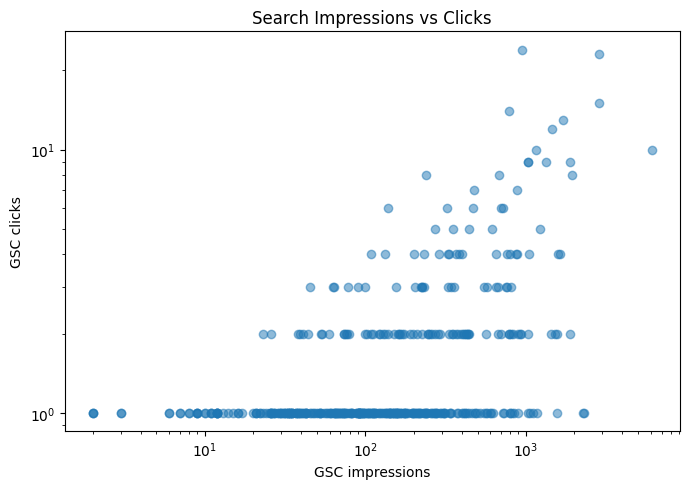

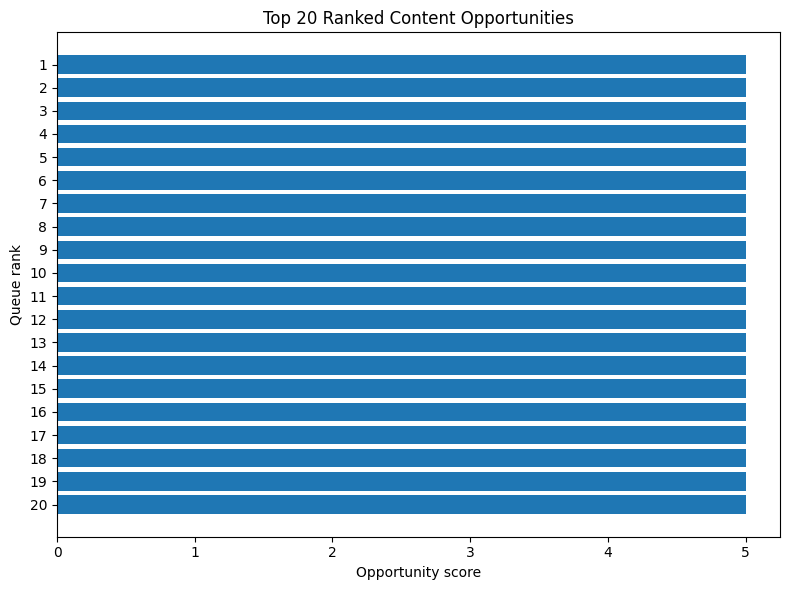

In [ ]:
# ============================================================
# 11. Paper figures
# ============================================================

os.makedirs("work/figures", exist_ok=True)

# Figure 1 — score distribution
plt.figure(figsize=(7, 4))

score_counts = (
    queue["opportunity_score"]
    .value_counts()
    .sort_index()
)

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.title("Distribution of Content Opportunity Scores")
plt.xlabel("Opportunity score")
plt.ylabel("Number of content items")
plt.tight_layout()

plt.savefig(
    "work/figures/opportunity_score_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 2 — reason codes
reason_counts = queue["reason_code"].value_counts()

plt.figure(figsize=(9, 5))

plt.barh(
    reason_counts.index,
    reason_counts.values
)

plt.title("Content Items by Reason Code")
plt.xlabel("Number of content items")
plt.ylabel("Reason code")

plt.tight_layout()

plt.savefig(
    "work/figures/reason_code_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 3 — impressions vs clicks
plt.figure(figsize=(7, 5))

positive_impressions = queue["gsc_impressions"] > 0
positive_clicks = queue["gsc_clicks"] > 0

plt.scatter(
    queue.loc[
        positive_impressions & positive_clicks,
        "gsc_impressions"
    ],
    queue.loc[
        positive_impressions & positive_clicks,
        "gsc_clicks"
    ],
    alpha=0.5
)

plt.title("Search Impressions vs Clicks")
plt.xlabel("GSC impressions")
plt.ylabel("GSC clicks")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()

plt.savefig(
    "work/figures/impressions_vs_clicks.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 4 — top 20
top20 = queue.head(20).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    top20["rank"].astype(str),
    top20["opportunity_score"]
)

plt.title("Top 20 Ranked Content Opportunities")
plt.xlabel("Opportunity score")
plt.ylabel("Queue rank")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "work/figures/top20_opportunities.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Reproducibility

The final research workflow builds on:

- `work/notebooks/w04_baseline_score.ipynb`
- `work/notebooks/w05_model.ipynb`
- `work/notebooks/w06_validation_audit.ipynb`
- `work/notebooks/w07_action_playbook.ipynb`
- `work/notebooks/capstone.ipynb`

Figures are stored under `work/figures/` and the ranked queue plus metrics
receipt are regenerated under `work/outputs/`.

The workflow is repeatable subject to access to the FlyRank ML Internship
dataset and the required Hugging Face access token.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

The dataset and internship learning environment provided the basis for this
analysis and the practical machine-learning workflow used throughout the
project.

Data source: [FlyRank](https://flyrank.ai)

## Final Self-Check

- [x] Research question stated
- [x] Decision supported stated
- [x] Data and table described
- [x] Exclusions explained
- [x] Method choice explained
- [x] Proxy label disclosed
- [x] Target-defining features excluded from audited model
- [x] Grouped validation used
- [x] Baseline and model evaluated on the same grouped test set
- [x] Leakage audit included
- [x] Error examples included
- [x] Results table included
- [x] Results chart included
- [x] Ranked recommendations included
- [x] Human review requirement stated
- [x] No-go automation boundaries stated
- [x] Limitations included
- [x] Public-safe claim language used
- [x] Reproducibility included
- [x] FlyRank data credit included
- [x] Figures exported to `work/figures/`
- [x] Queue and metrics exported to `work/outputs/`
